# 회귀 스플라인으로 비선형 신용 부도 위험 모델링하기

## 요약

소매 은행 위험 팀은 프로덕션 스코어카드에 착수하기 전에 부도 위험이 *어디서* 비선형으로 바뀌는지 알아야 한다. 모든 특성을 손으로 미리 구간화하는 대신, 팀은 `PROC GAM`으로 **일반화 가법 모형(GAM)**을 적합한다: 각 차입자 특성이 3차 평활 스플라인으로 들어가므로, 임계점 및 U자형 관계가 로짓 척도에서 데이터로부터 직접 추정된다. 의도적으로 불리하게 구성한 100건 대출(39% 부도)의 합성 포트폴리오에서, 가법 스플라인 모형은 이탈도(deviance)를 133.75(절편만)에서 61.69로 낮춘다 — 72.06 감소 — 모형 AIC는 81.69이다. 적합된 부채비율(debt-to-income) 평활이 가장 큰 계수(4.34)를 가지며, 원시 결과를 구간화하면 설계된 구조가 확인된다: 부도 위험은 **연령에 대해 뚜렷한 U자형**(최연소 차입자 66.7%, 중년 4.8%, 최고령자 86.4%)이며 레버리지와 함께 위로 표류한다.

## 데이터 출처

| 데이터셋 | 행 수 | 역할 | 주요 변수 | 설명 |
|---------|------|------|---------------|-------------|
| `loans` | 100 | 모델링 입력 | `default`(0/1 목표), `age`, `dti`(부채비율), `utilization`(회전 신용 사용) | 합성 소매 대출 신청. 실제 부도 로그-오즈는 의도적인 비선형성으로 구성되며 — U자형 연령 효과와 부채비율 및 사용률의 임계 힌지 — 그 후 베르누이 표집된다. `call streaminit(20260531)`과 `rand()`로 인라인 생성; 외부 파일 없음. |

이 환경은 라이선스 없이 실행되므로 출력은 100개 관측치로 제한된다. 시나리오는 그 제한에 맞춰 설계되었다: 세 항 가법 스플라인 모형이 100건의 대출에서 형태를 복원할 수 있을 만큼 신호가 충분히 강하게 설정되어 있다.

# 신용 위험에 왜 스플라인인가

전통적인 스코어카드는 수동으로 구간화한 변수(증거 가중치 / 정보 가치)를 사용한 로지스틱 회귀에 의존한다. 그것은 작동하지만, 위험 임계점과 곡률이 어디에 있는지 분석가가 *추측*하도록 강요한다. **일반화 가법 모형(GAM)**은 각 선형 항을 평활 함수 — 여기서는 자유도 3의 3차 평활 스플라인 — 로 대체하므로, 곡선 형태가 가정되는 것이 아니라 추정된다. `PROC GAM`은 이진 목표에 대해 이 평활들을 로짓 척도에서 적합하는데, 이것이 바로 부도 확률 모형의 설정이다.

이 노트북에서 우리는 소매 은행 위험 팀의 역할을 맡는다. 우리는:

1. **실제** 부도 확률이 진정으로 비선형인(U자형 연령 효과와 부채비율 및 사용률의 임계 효과) 합성 대출 포트폴리오를 생성한다.
2. 이항/로짓 가법 스플라인 모형을 적합하고 이탈도, AIC, 평활별 계수를 읽는다.
3. 원시 부도 결과를 구간화하고 `PROC SGPLOT`으로 그려 복원된 형태를 확인한다.

여기서 외부 데이터나 네트워크 연결이 필요한 것은 없다.

## 1단계 - 합성 대출 포트폴리오 구축

우리는 100건의 대출 신청을 시뮬레이션한다. 각 차입자는 세 개의 특성을 가진다. **부도 로그-오즈**는 의도적으로 비선형인 구성 요소로 만들어지므로, 스플라인 모형이 복원할 알려진 정답이 존재한다:

- **연령** - U자 형태: 부도 위험은 매우 젊거나 매우 나이 든 차입자에게서 높고 중년에서 가장 낮다. 우리는 이를 제곱된 중심화 연령 항으로 부호화한다.
- **DTI** - 임계 효과: 부채비율이 약 0.35를 넘기 전까지는 영향이 거의 없다가 그 후 위험이 상승한다(단측 힌지).
- **사용률** - 회전 신용 한도의 약 0.60에서의 두 번째 힌지.

그런 다음 이진 `default` 플래그가 해당 확률을 갖는 베르누이 분포로부터 추출된다. 절편은 높은 기저가 아니라 설계된 비선형성이 부도를 유발하도록 충분히 낮게 설정된다 — 이는 100건의 대출만으로 형태가 보이도록 선택된, 의도적으로 불리한 고위험 포트폴리오이다.

In [1]:
데이터 loans;
   호출 streaminit(20260531);

   반복 id = 1 까지 100;
      /* ---- 차입자 특성 ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 세    */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* 부채비율       */
      utilization = rand("UNIFORM");               /* 한도의 0 .. 1  */

      /* ---- 실제 비선형 부도 로그-오즈 ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U자형     */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* 임계 힌지 */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* 임계 힌지 */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      제거 age_c eta_age eta_dti eta_util eta p_true;
      출력;
   종료;
실행;

처리 평균 데이터=loans n mean MIN MAX maxdec=3;
   변수 default AGE dti utilization;
   라벨 default="부도" AGE="연령" dti="부채비율" utilization="사용률";
실행;

                                                  The MEANS Procedure

 Variable     Label                N           Mean     Minimum     Maximum
 --------------------------------------------------------------------------
 default      부도                 100          0.390       0.000       1.000
 AGE          연령                 100         44.993      18.342      69.646
 dti          부채비율               100          0.312       0.059       0.590
 utilization  사용률                100          0.548       0.012       0.988
 --------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`PROC MEANS` 요약은 포트폴리오를 확인해 준다: 전체 부도율 **39%**(스트레스가 있는 고위험 장부), 연령은 18-70에 걸치고, 부채비율은 평균 0.31, 사용률은 전체 0-1 범위에서 평균 0.55이다. 데이터를 확보했으니 모형을 적합할 수 있다.

## 2단계 - 가법 스플라인 모형 적합

`MODEL` 문은 이진 반응변수를 지정하고 각 예측변수를 `spline(var, df=3)`으로 감싸, 각각 자유도 3의 3차 평활 스플라인을 요청한다. 옵션:

- `event='1'` - 비사건이 아니라 *부도* 사건의 확률을 모델링한다.
- `dist=binomial` - 로짓 척도에서 적합되는 0/1 목표로, 부도 확률에 자연스러운 선택이다.

`PROC GAM`은 모형 **이탈도**와 **AIC**, 각 평활 항의 계수, 그리고 구성 요소당 소비된 자유도를 나열하는 평활-모형 표를 보고한다.

In [2]:
제목 "대출 부도의 일반화 가법 로지스틱 모형";

처리 gam 데이터=loans;
   모형 default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   라벨 default="부도" AGE="연령" dti="부채비율" utilization="사용률";
실행;

제목;

                                                 대출 부도의 일반화 가법 로지스틱 모형                                                  


                                                   The GAM Procedure                                                    

Model Information
Response Variable     부도
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(연령)  


NOTE: Option TITLE changed to 대출 부도의 일반화 가법 로지스틱 모형.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


적합은 강력하다. **영 이탈도** 133.75(절편만 있는 모형)는 세 평활이 추가되면 잔차 **이탈도 61.69**로 떨어지며 — 72.06 감소 — 모형 **AIC는 81.69**이다. 평활 항들 중에서 **부채비율 스플라인이 가장 큰 계수(4.34)**를 가지며, 연령 및 사용률 평활을 앞서 레버리지를 적합된 로그-오즈의 지배적 요인으로 식별한다. 각 평활은 요청대로 자유도 3을 소비한다. 모형은 우리가 단 하나의 구간이나 다항식 항도 지정하지 않고도 이 관계들이 비선형임을 발견했다.

## 3단계 - 복원된 형태 확인

적합된 평활은 원시 데이터와 일치할 때에만 설득력이 있다. 우리는 각 차입자를 연령과 부채비율로 구간화하고, `PROC MEANS`로 각 구간에서 실현된 부도율을 계산하며, `PROC SGPLOT`으로 그린다. 스플라인 모형이 진실을 말하고 있다면, 구간화된 결과는 모형이 적합한 것과 동일한 U자형과 임계점을 따라야 한다.

In [3]:
데이터 binned;
   설정 loans;
   길이 dti_band $9 age_band $5;

   만약      dti < 0.20 이면 dti_band = "0.00-0.20";
   아니면 만약 dti < 0.30 이면 dti_band = "0.20-0.30";
   아니면 만약 dti < 0.40 이면 dti_band = "0.30-0.40";
   아니면 만약 dti < 0.50 이면 dti_band = "0.40-0.50";
   아니면                    dti_band = "0.50+";

   만약      AGE < 30 이면 age_band = "18-30";
   아니면 만약 AGE < 40 이면 age_band = "30-40";
   아니면 만약 AGE < 50 이면 age_band = "40-50";
   아니면 만약 AGE < 60 이면 age_band = "50-60";
   아니면                  age_band = "60-70";
실행;

처리 평균 데이터=binned NWAY NOPRINT;
   분류 age_band;
   변수 default;
   출력 out=age_rate(제거=_type_ _freq_)
          n=n mean(default)=def_rate;
실행;

처리 평균 데이터=binned NWAY NOPRINT;
   분류 dti_band;
   변수 default;
   출력 out=dti_rate(제거=_type_ _freq_)
          n=n mean(default)=def_rate;
실행;

처리 인쇄 데이터=age_rate noobs 라벨;
   변수 age_band n def_rate;
   라벨 age_band="연령 구간" n="계좌 수" def_rate="부도율";
   형식 def_rate percent8.1;
실행;

처리 인쇄 데이터=dti_rate noobs 라벨;
   변수 dti_band n def_rate;
   라벨 dti_band="부채비율 구간" n="계좌 수"
         def_rate="부도율";
   형식 def_rate percent8.1;
실행;


        연령 구간        계좌 수        부도율
-------------  ----------  ---------
18-30                  21      66.7%
30-40                  19      10.5%
40-50                  21       4.8%
50-60                  17      17.6%
60-70                  22      86.4%

            부채비율 구간        계좌 수        부도율
-------------------  ----------  ---------
0.00-0.20                    29      37.9%
0.20-0.30                    21      28.6%
0.30-0.40                    15      33.3%
0.40-0.50                    20      50.0%
0.50+                        15      46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


연령 구간은 깔끔한 U를 그린다: 30세 미만 차입자의 **66.7%**가 부도를 냈고, 부도율은 40-50 구간에서 **4.8%**로 바닥을 친 뒤, 60세 이상 차입자에서 **86.4%**로 다시 상승한다. 부채비율 구간은 전반적으로 위로 표류한다 — 최저 구간의 30% 후반대에서 DTI 0.40을 넘어서면 대략 50%로 — 다만 100건의 대출만으로는 구간별 비율이 잡음이 많은데, 이것이 바로 단일한 경성 컷오프가 아니라 모형의 평활이 더 신뢰할 만한 요약인 이유이다. 아래 그림은 두 형태를 모두 보여준다.

### 연령 효과는 U자형이다

연령 구간별 실현 부도율을 그리면 스플라인이 복원한 곡률이 드러난다: 연령 범위 양 끝에서 높은 위험, 중년에서 깊은 골짜기.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


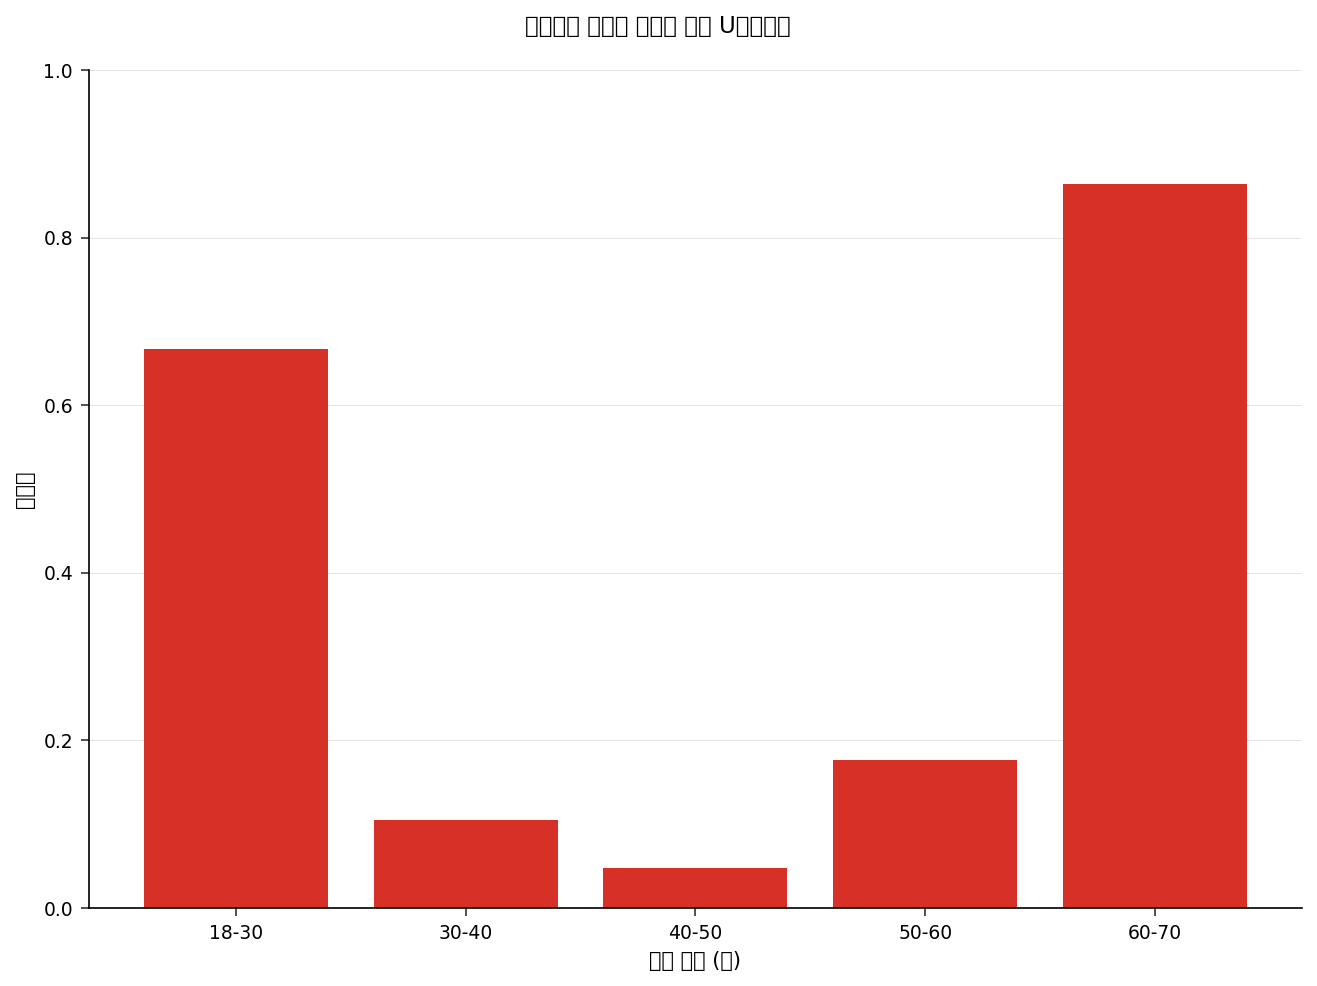

In [4]:
ODS GRAPHICS ON;

처리 SGPLOT 데이터=age_rate noautolegend;
   제목 "부도율은 차입자 연령에 대해 U자형이다";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS 라벨="부도율" VALUES=(0 까지 1 기준 0.2) grid;
   XAXIS 라벨="연령 구간 (세)";
실행;

제목;
ODS GRAPHICS OFF;

### 위험은 레버리지와 함께 위로 표류한다

부채비율 구간은 위로 향하는 추세를 보인다 — 가장 레버리지가 높은 차입자가 가장 자주 부도를 낸다 — 이는 모형의 지배적인 DTI 평활과 일치한다. 이 표본 크기에서 중간 구간들은 잡음이 많은데, 이는 적합된 스플라인이 손으로 그린 어떤 단일 컷오프보다 더 안정적인 지침인 이유를 강조한다.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


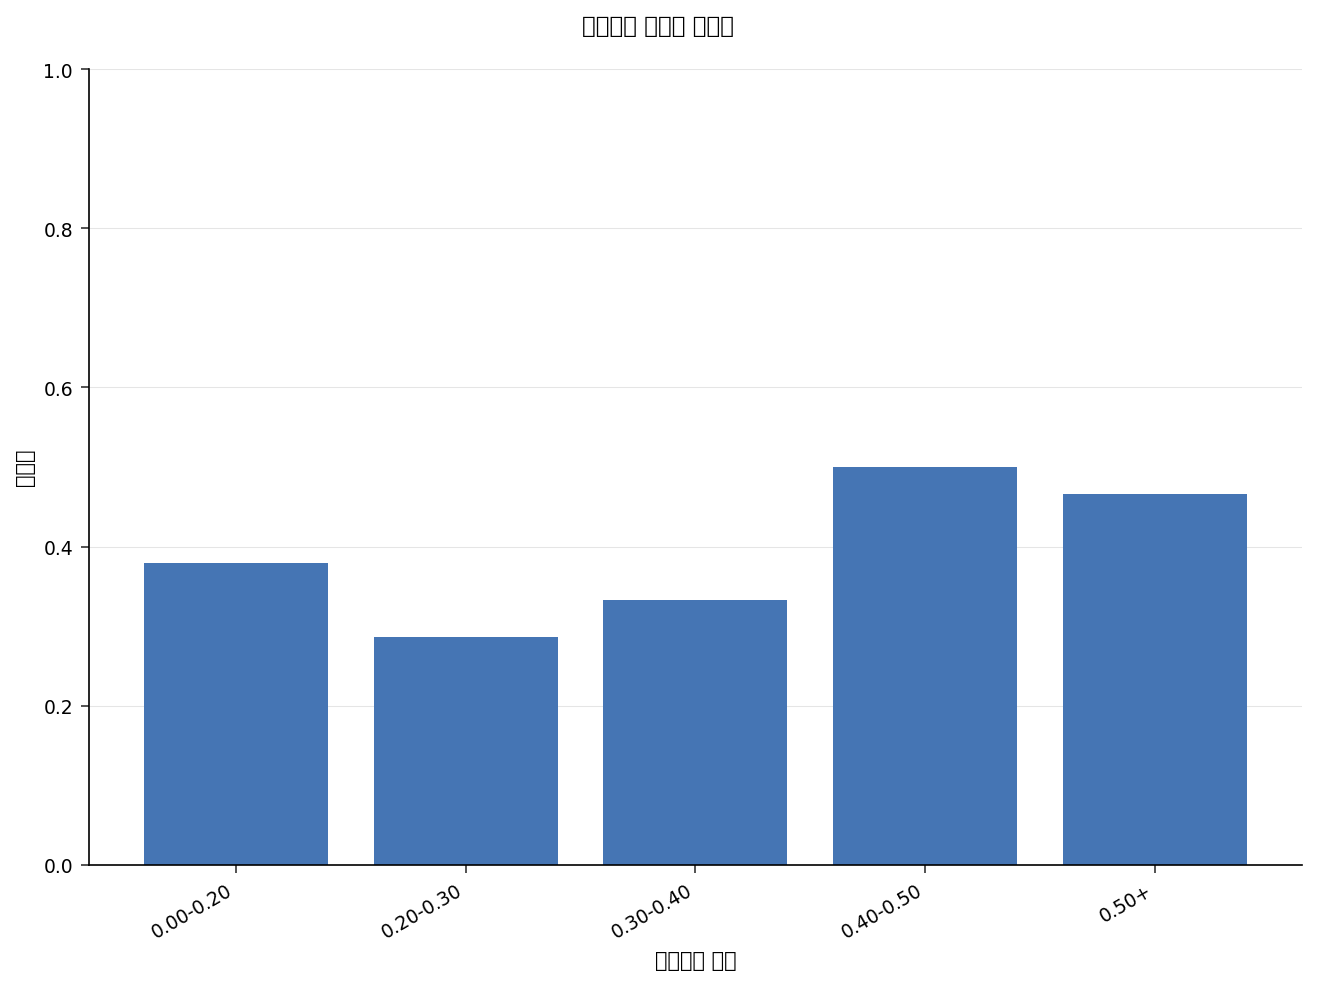

In [5]:
ODS GRAPHICS ON;

처리 SGPLOT 데이터=dti_rate noautolegend;
   제목 "부채비율 구간별 부도율";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS 라벨="부도율" VALUES=(0 까지 1 기준 0.2) grid;
   XAXIS 라벨="부채비율 구간";
실행;

제목;
ODS GRAPHICS OFF;

## 결과 해석

`PROC GAM`은 어떤 수동 구간화나 다항식 항 없이도 우리가 합성 포트폴리오에 심어둔 비선형 구조를 복원했다:

- **강한 전체 적합** - 가법 스플라인 모형은 39% 기저 부도율의 장부에서 이탈도를 133.75에서 61.69로 낮추며(72.06 감소) 모형 AIC 81.69를 낸다.
- **레버리지가 지배한다** - 부채비율 평활이 세 항 중 가장 큰 계수(4.34)를 가지며, DTI를 적합된 로그-오즈의 주요 요인으로 표시한다.
- **연령의 곡률** - 원시 결과를 구간화하면 교과서적인 U가 확인된다: 30세 미만 구간에서 66.7% 부도, 40-50에서 4.8%의 골짜기, 60세 이상 구간에서 86.4% — 3차 스플라인은 자연스럽게 포착하지만 단일 선형 연령 항은 완전히 놓칠 형태이다.
- **잡음에 대한 정직함** - 100건의 대출에서 구간별 부채비율 비율은 흔들리는데, 이는 바로 경성으로 손수 선택한 컷오프보다 평활 추정이 나은 경우이다.

**이것이 은행업에 중요한 이유:** 가법 스플라인은 위험 팀에게 프로덕션 스코어카드에 착수하기 전에 관계가 진정으로 비선형인 지점을 빠르고 자동으로 감지하는 방법을 제공한다. 적합된 평활은 위험 곡선으로 직접 해석 가능하며 — 젊고 나이 든 연령 프리미엄, 레버리지 경사 — 이탈도와 AIC는 그 유연성이 평평한 선형 모형에 비해 얼마나 이득이 되는지를 정량화한다.